In [27]:
# Copyright (c) Meta Platforms, Inc. and affiliates.
# and David Edel
# This source code is licensed under the MIT license found in the
# LICENSE file in the root directory of this source tree.

"""Simple example of QAT using DDP (ResNet on CIFAR-10)
Adapted from https://github.com/akamaster/pytorch_resnet_cifar10"""
# os.environ["TORCH_LOGS"]="recompiles"
import torch
import torch._dynamo

torch._dynamo.config.cache_size_limit = 64
torch._dynamo.config.recompile_limit = 64
# torch._dynamo.config.verbose = True
# torch._inductor.config.debug = True

import json
import torch.nn as nn
from torchvision import transforms as T
from torch import optim

import itertools

from model import resnet
from model.resnet import ResNet,BasicBlock
import wandb
import time


from tqpmod.parq_utils import (
    NORM_LAYERS,
    get_param_groups,
    split_param_groups,
)
from tqpmod.tqp_optimizer_scale_train import TQPS
# from tqpmod.softbinning import SoftBinning # replace with custom
from tqpmod.logging_utils import init_loger_and_folder
from tqpmod.train_eval import evaluate

import math # for nan check

DEVICE = torch.device("cuda:0")
torch.set_float32_matmul_precision("high")  # improves matmul speed
import matplotlib.pyplot as plt


In [28]:
class SoftBinningScale:
    def __init__(self, bins=3):
        if bins < 3 or bins % 2 != 1:
            raise ValueError("bins must be odd >= 3")
        self.bins = bins // 2
        self.max = self.bins

    @torch.no_grad()
    @torch.compile()
    def call_test(self, x: torch.Tensor):
        x = torch.abs(x)
        y = 1 - self.max + x
        mask = x < self.max
        y[mask] = x[mask] - torch.floor(x[mask])
        y = y * torch.abs(1 - y)
        return y

    def compute_xright_quantile(self, x: torch.Tensor):
        x, _ = x.clone().detach().flatten().sort()
        third = x[x.shape[0] // 3]
        two_thirds = x[int(x.shape[0] * (2 / 3))]
        return third.abs() + two_thirds.abs()


soft_binning = SoftBinningScale(3)

In [29]:
from itertools import chain
@torch.compile()
@torch.no_grad()
def calc_reg_loss_vit(
    optimizer:TQPS,
    soft_binning: SoftBinningScale,
    n_params,
    attn_params,
    factors,
    device=torch.device("cuda:0"),
    M=1,
    beta=5e-4,
    
    compute_per_layer_share_done = False
):
    """
    returns tuple of:
    avg_reg_loss, a norm, %done
    """

    reg_loss = torch.zeros((), device=device, requires_grad=False)
    quantized_params = torch.zeros(
        (), device=device, requires_grad=False, dtype=torch.int64
    )
    norm = torch.zeros((), device=device, requires_grad=False)
    per_layer_share_done = torch.zeros((len(optimizer.regularized_params) + len(factors)))
    for i, param in enumerate( chain(optimizer.regularized_params,[param.detach() / fac for fac,param in zip(factors,attn_params)])):
        
        reg_loss += soft_binning.call_test(param.detach()).sum().detach()

        calc_param = param.detach()
        quantized_this_param = (
            (abs(calc_param - calc_param.round().clip(-M, M)) < (beta / 2))
            .sum()
            .to(torch.int64))
        quantized_params += quantized_this_param
        
        per_layer_share_done[i] = quantized_this_param / param.numel()
        norm += param.norm().detach()

    return (reg_loss / n_params).item(), norm.sqrt().item(), (quantized_params / n_params).item(), per_layer_share_done

In [30]:
@torch.no_grad()
def factor_function_test(params):
    return (params.flatten().std() * 2 * 0.5) * torch.ones((params.shape[0],),device=params.device)# / 1.16
    # the 0.5 and 2 cancel, but leave them in because we could adjust the params for this

(array([100., 100., 100., 100., 100., 100., 100., 100., 100., 100.]),
 array([-1.72945428, -1.3835634 , -1.03767252, -0.69178176, -0.34589088,
         0.        ,  0.34589076,  0.69178176,  1.03767252,  1.38356328,
         1.72945428]),
 <BarContainer object of 10 artists>)

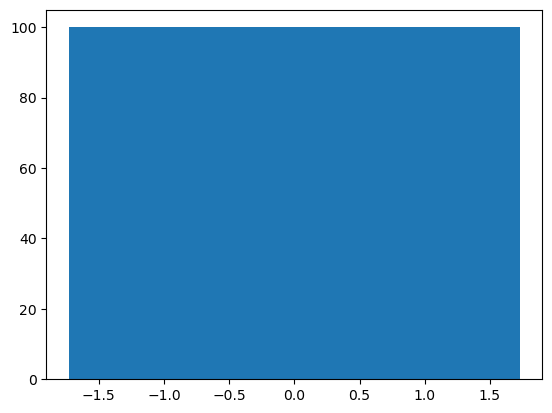

In [31]:
x = torch.linspace(-3.5,3.5,1000)
fac = factor_function_test(x)
plt.hist(x / fac)

[np.float64(0.1), np.float64(0.2), np.float64(0.3), np.float64(0.4), np.float64(0.5), np.float64(0.6), np.float64(0.7), np.float64(0.8), np.float64(0.9), np.float64(1.0), np.float64(1.0), np.float64(0.9996984292173742), np.float64(0.9987940842870415), np.float64(0.9972880670139965), np.float64(0.9951822122483021), np.float64(0.992479085649608), np.float64(0.9891819805612899), np.float64(0.985294913998018), np.float64(0.980822621751643), np.float64(0.9757705526213631), np.float64(0.9701448617752022), np.float64(0.9639524032508848), np.float64(0.9572007216052479), np.float64(0.9498980427223599), np.float64(0.942053263791548), np.float64(0.9336759424675439), np.float64(0.9247762852259533), np.float64(0.9153651349282385), np.float64(0.9054539576113602), np.float64(0.8950548285181792), np.float64(0.8841804173856326), np.float64(0.872843973008611), np.float64(0.8610593070983421), np.float64(0.8488407774549491), np.float64(0.8362032704746823), np.float64(0.8231621830131383), np.float64(0.8097

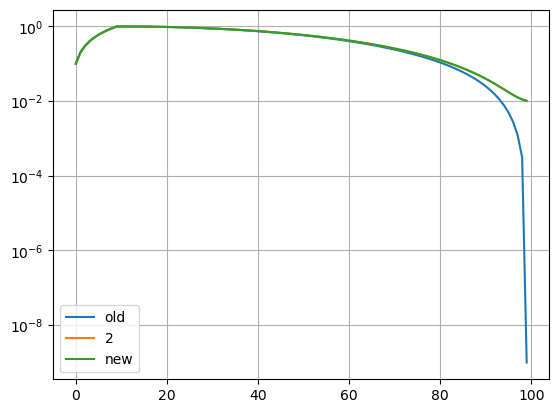

In [32]:
import numpy as np
num_epochs = 100
lr_warmup_epochs = 10
num_epochs_lr_schedule = 99
new_cos_epoch = 55
def get_lr_factor(epoch):
    if epoch < lr_warmup_epochs:
        return (epoch + 1) / lr_warmup_epochs
    elif epoch > num_epochs_lr_schedule:
        return get_lr_factor(num_epochs_lr_schedule)
    else:
        return max(
            [
                0.5
                * (
                    1
                    + np.cos(
                        np.pi
                        * (epoch - lr_warmup_epochs)
                        / (num_epochs_lr_schedule - lr_warmup_epochs)
                    )
                ) ,
                1e-9,
            ]
        )
def build_lr_factor(lr_warmup_epochs,num_epochs ):
    min_lr_factor = 1e-2

    def get_lr_factor(epoch):
        if epoch < lr_warmup_epochs:
            return (epoch + 1) / lr_warmup_epochs
        elif epoch > num_epochs:
            return get_lr_factor(num_epochs)
        else:
            return ((
                1
                + np.cos(
                    np.pi
                    * (epoch - lr_warmup_epochs)
                    / (num_epochs - lr_warmup_epochs)
                )
            ) / (2)  + min_lr_factor )/ (1+min_lr_factor)
                    

    return get_lr_factor
def build_lr_factor_new(lr_warmup_epochs,num_epochs ):
    min_lr_factor = 1e-2

    def get_lr_factor(epoch):
        if epoch < lr_warmup_epochs:
            return (epoch + 1) / lr_warmup_epochs
        elif epoch > num_epochs:
            return get_lr_factor(num_epochs)
        else:
            return (
                1 + 2 * min_lr_factor
                + np.cos(
                    np.pi
                    * (epoch - lr_warmup_epochs)
                    / (num_epochs - lr_warmup_epochs)
                )
            ) / (2+2*min_lr_factor)
                    

    return get_lr_factor

get_lr_factor_2 = build_lr_factor(
    lr_warmup_epochs, num_epochs
)
get_lr_factor_new = build_lr_factor_new(
    lr_warmup_epochs, num_epochs
)
x = np.arange(100)
y = [get_lr_factor(xi) for xi in x]
z = [get_lr_factor_2(xi) for xi in x]
z_new = [get_lr_factor_new(xi) for xi in x]
print(z)
plt.plot(x,y,label="old")
plt.plot(x,z,label="2"),
plt.plot(x,z_new,label="new"),
plt.legend()
plt.grid()
plt.yscale("log")

In [33]:
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
from torchvision.models import vit_b_16, ViT_B_16_Weights

train_transform = transforms.Compose(
    [
        transforms.RandomCrop(32, padding=4),
        transforms.Resize(224),  # ViT expects 224x224 images
        transforms.RandomHorizontalFlip(),
        transforms.RandAugment(num_ops=2, magnitude=9),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
    ]
)

test_transform = transforms.Compose(
    [
        transforms.Resize(224),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
    ]
)


def create_data_loaders_vit(batch_size):
    train_dataset = torchvision.datasets.CIFAR10(
        root="~/data", train=True, download=True, transform=train_transform
    )
    test_dataset = torchvision.datasets.CIFAR10(
        root="~/data", train=False, download=True, transform=test_transform
    )

    # train_subset = Subset(train_dataset, torch.arange(128))

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=8,
        pin_memory=True,
        persistent_workers=True,
        drop_last=True,
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=256,
        shuffle=False,
        num_workers=8,
        pin_memory=True,
        persistent_workers=True,
    )
    return train_loader,test_loader

In [34]:
print("def proximal mapping")
@torch.compile(dynamic=False)
@torch.no_grad()
def proximal_mapping(theta_old: torch.Tensor, beta: torch.Tensor):
    # factor replaces the one
    # this means that factor * one = factor, which is where the slope will be 0 after the transformation
    """
    assume beta < 1 and M = 1
    will handle every tensor row-wise, so (A,B,C) will be treated as (A,B*C)
    """

    theta_new = theta_old
    a0 = beta / 2
    abs_theta = abs(theta_new)
    y = torch.where(abs_theta < a0, 0, abs_theta / (1 - beta) - (1 / (1 - beta) * a0))
    # y[abs_theta>(1-a0)]=1
    y = torch.where(abs_theta > (1 - a0), 1, y)
    y = torch.where(
        abs_theta > 1 + a0,
        abs_theta / (1 + beta) + (1 - ((1 + beta / 2) / (1 + beta))),
        y,
    )
    return y * torch.sign(theta_new)

def proximal mapping


In [35]:
@torch.no_grad()
def prox_step_att_params(params:list[nn.Parameter], factors,beta):
    for param,factors in zip(params,factors):
        param.copy_(proximal_mapping(param.data / factors,beta) * factors) 

In [36]:
from tqdm import tqdm


def train_epoch(model, loader, criterion, optimizer, scaler, device, attn_params,factors,beta,amp=True):
    model.train()
    running_loss = torch.zeros((), device=device)
    correct = torch.zeros((), device=device)
    total = 0  # cpu side, because we add ints to it (from shape) which are already on cpu and dont need to sync with the gpu

    pbar = tqdm(loader, desc="Training")
    optimizer.base_optimizer.zero_grad()
    for images, labels in pbar:

        torch.compiler.cudagraph_mark_step_begin()
        images: torch.Tensor
        labels: torch.Tensor
        images, labels = images.to(device, non_blocking=True), labels.to(
            device, non_blocking=True
        )
        # Mixed precision training
        with torch.amp.autocast("cuda",enabled=amp):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        prox_step_att_params(attn_params,factors,beta)
        scaler.update()
        optimizer.base_optimizer.zero_grad()
        with torch.no_grad():
            running_loss += loss.detach()
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().detach()
            total += labels.size(0)


    avg_loss = running_loss.item() / len(loader)
    avg_accuracy = 100.0 * correct.item() / total
    #logger.info(f"loss {avg_loss:.4f}   acc {avg_accuracy:.2f}%")
    return avg_loss, avg_accuracy

In [37]:
weights = None
model = vit_b_16(weights=weights)  # remove weights to use unpretrained

# Modify the final classifier for CIFAR-10 (10 classes)
model.heads.head = nn.Linear(model.heads.head.in_features, 10)
def get_attn_weights(model:nn.Module):
    attn_params = []
    factors = []
    for name,param in model.named_parameters():
        if "self_attention" in name and "weight" in name:
            print("in: ",name)
            attn_params.append(param)
            factors.append(param.std(correction=0))
        else:
            #print("out:",name)
            pass
    return attn_params,factors

In [38]:

from tqpmod.model_utils import ScaleLayer
from tqpmod.tqp_optimizer import equisplit


@torch.no_grad()
def inject_scale_layers_no_factor(
    model: nn.Module,
    param_dicts_list: list,
    learning_rate=0.1,
    weight_decay=2e-4,
    scale_grad = True,
):
    for name, child in model.named_children():
        # Check for both Linear and Conv2d
        if "self_attention" in name: 
            print(name)
            continue
        if isinstance(child, (nn.Linear, nn.Conv2d)):
            # Create a sequence: Original Layer -> Test Layer

            scale_shape = (1, child.weight.shape[0])

            if isinstance(child, nn.Conv2d):
                scale_shape = (*scale_shape, 1, 1)  # append 1,1 to shape for conv
            if child.bias is not None:
                if isinstance(child, nn.Conv2d):
                    print("TODO: check if this bias is correct for conv2d bias")
                param_dicts_list.append(  
                {
                    "params": [child.bias],
                    "weight_decay": 0,
                    "lr": (learning_rate),
                }
            )
            scale = ScaleLayer(scale_shape).to(child.weight.device)
            scale.scale.requires_grad=scale_grad
            new_block = nn.Sequential(child, scale)
            
            # Replace the attribute on the model
            setattr(model, name, new_block)
            param_dicts_list.append( 
                {
                    "params": [child.weight],
                    "quant_bits": 0,
                    "weight_decay": (weight_decay),
                    "lr": (learning_rate),
                }
            )
            

        else:
            # Recurse for nested modules (like Bottlenecks in ResNet)

            inject_scale_layers_no_factor(
                child,
                param_dicts_list,
                learning_rate=learning_rate,
                weight_decay=weight_decay,
                scale_grad=scale_grad
            )

@torch.no_grad()
def rebalance_layers(
    model: nn.Module,
    param_dict: dict[nn.Parameter,dict],
    lr_schedule:torch.optim.lr_scheduler.LRScheduler,
    optimizer: torch.optim,
    dtype_target=torch.float32,
    dtype_calc=torch.float64,
    factor_function=equisplit,
    factor_function_args=(),
    factor_power = 1,
):
    for name, child in model.named_children():
        if "self_attention" in name:
            print(name)
            continue
        if isinstance(child,nn.Sequential) and (len(child) == 2) and isinstance(child[1],ScaleLayer):
            linear:nn.Linear | nn.Conv2d = child[0]
            scale:ScaleLayer = child[1]
            scale_shape = scale.scale.shape
            # if "conv1" in name:
            #     bn = model.bn1                
            # elif "conv2" in name:
            #     bn = model.bn2
            # else:
            #     # for the linear layer at the end:
            #     # bn = nn.BatchNorm2d(torch.numel(scale_shape)) # dummy batchnorm that gets destroyed at function close.
            #     pass
            # bn:nn.BatchNorm2d
            

            
            factors = factor_function(
                linear.weight.to(dtype_calc), *factor_function_args
            )
            factors = factors.reshape((-1, 1))#.to(dtype_target)

            if isinstance(linear, nn.Conv2d):
                factors = factors.reshape((*factors.shape, 1, 1))

            linear.weight.copy_(
                (linear.weight.detach().to(dtype_calc) / factors).to(dtype_target)
            )
            param_dict[linear.weight]["group"]["lr"] = param_dict[linear.weight]["group"]["lr"] * ((1 / factors.mean()) ** factor_power).to(
                        dtype_target
                    ).item()
            index_weight = param_dict[linear.weight]["index"]
            lr_schedule.base_lrs[index_weight]=lr_schedule.base_lrs[index_weight] * ((1 / factors.mean()) ** factor_power).to(
                        dtype_target
                    ).item()
            
            param_dict[linear.weight]["group"]["weight_decay"] = param_dict[linear.weight]["group"]["weight_decay"] * (factors.mean() ** factor_power).to(
                        dtype_target
                    ).item()
            if "momentum_buffer" in optimizer.base_optimizer.state[linear.weight].keys(): #SGDM
                optimizer.base_optimizer.state[linear.weight]["momentum_buffer"].mul_(factors.to(dtype_target))
            if "exp_avg" in optimizer.base_optimizer.state[linear.weight].keys(): #ADAM
                optimizer.base_optimizer.state[linear.weight]["exp_avg"].mul_(factors.to(dtype_target))
            if "exp_avg_sq" in optimizer.base_optimizer.state[linear.weight].keys():# ADAM
                optimizer.base_optimizer.state[linear.weight]["exp_avg_sq"].mul_((factors ** 2).to(dtype_target))
            if linear.bias is not None:
                if isinstance(linear, nn.Conv2d):
                    print("TODO: check if this bias is correct for conv2d bias")
                linear.bias.div_(factors.flatten())
                param_dict[linear.bias]["group"]["lr"] = param_dict[linear.bias]["group"]["lr"] * ((1 / factors.mean()) ** factor_power).to(
                        dtype_target
                    ).item()
                index_bias = param_dict[linear.bias]["index"]
                lr_schedule.base_lrs[index_bias]=lr_schedule.base_lrs[index_bias] * ((1 / factors.mean()) ** factor_power).to(
                        dtype_target
                    ).item()
                if "momentum_buffer" in optimizer.base_optimizer.state[linear.bias].keys():
                    optimizer.base_optimizer.state[linear.bias]["momentum_buffer"].mul_(factors.flatten().to(dtype_target))
                if "exp_avg" in optimizer.base_optimizer.state[linear.bias].keys():
                    optimizer.base_optimizer.state[linear.bias]["exp_avg"].mul_(factors.flatten().to(dtype_target))
                if "exp_avg_sq" in optimizer.base_optimizer.state[linear.bias].keys():
                    optimizer.base_optimizer.state[linear.bias]["exp_avg_sq"].mul_((factors.flatten() ** 2).to(dtype_target))

            scale.scale.mul_(factors.reshape(scale_shape).to(dtype_target))

            # BatchNorm scale:
            # stays the same

            # TODO: maybe also scale: scale lr.
        else:
            rebalance_layers(
                child,
                param_dict=param_dict,
                lr_schedule=lr_schedule,
                optimizer=optimizer,
                dtype_target=dtype_target,
                dtype_calc=dtype_calc,
                factor_function=factor_function,
                factor_function_args=factor_function_args,
                factor_power=factor_power,
            )


In [39]:
from typing import Any, Callable


def longrun_scale_layer(
    beta, train_params: dict[str, Any], run_name: str = "ScaleLayerTrain"
):
    try:
        logger, folder = init_loger_and_folder(run_name)
        history = {
            "train_loss": [],
            "train_acc": [],
            "test_loss": [],
            "test_acc": [],
            "reg_loss": [],
            "norm": [],
            "per_layer_share_done": [],
            "beta": [],
        }

        # ALL these hyperparams could get overwritten by train_params
        num_epochs = 70  
        learning_rate = 1e-4 # maybe lower
        weight_decay = 1e-2 # maybe even 5e-2

        lr_warmup_epochs = 3

        REG_wait_epochs = 6  # 55

        SEED = torch.randint(0, 10000, (1,))
        batch_size = 64

        inject_scales = True

        if train_params is not None:
            num_epochs = train_params.get("num_epochs", num_epochs)
            num_epochs_lr_schedule = num_epochs - 1
            num_epochs_lr_schedule = train_params.get(
                "num_epochs_lr_schedule", num_epochs_lr_schedule
            )
            learning_rate = train_params.get("learning_rate", learning_rate)
            weight_decay = train_params.get("weight_decay", weight_decay)
            lr_warmup_epochs = train_params.get("lr_warmup_epochs", lr_warmup_epochs)
            REG_wait_epochs = train_params.get("REG_wait_epochs", REG_wait_epochs)
            SEED = train_params.get("SEED", SEED)

            batch_size = train_params.get("batch_size", batch_size)

            inject_scales = train_params.get("inject_scales", inject_scales)

        torch.manual_seed(SEED)

        train_loader, val_loader = create_data_loaders_vit(
            batch_size,
        )
        steps_per_epoch = len(train_loader)

        # define loss function (criterion) and optimizer
        scaler = torch.amp.GradScaler("cuda")
        label_smoothing = 0.1
        criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing).to(DEVICE)  #
        USE_PRETRAINED = True
        if USE_PRETRAINED:
            weights = ViT_B_16_Weights.IMAGENET1K_V1
        else:
            weights = None
        model = vit_b_16(weights=weights) 
        model.heads.head = nn.Linear(model.heads.head.in_features, 10)
        param_groups = []
        # TOD:
        rest_group = []
        names = {
            param: name for name, param in model.named_parameters()
        }  # for debugging

        if inject_scales:
            inject_scale_layers_no_factor(
                model,
                param_groups,
                learning_rate=learning_rate,
                weight_decay=weight_decay,
                scale_grad=False,
            )
        else: # disables scale train
            param_groups.append(
                {
                    "params": [param for param in model.parameters() if len(param.shape) > 1],
                    "quant_bits": 32,
                    "weight_decay": weight_decay,
                    "learning_rate": learning_rate,
                }
            )
        attn_params,factors = get_attn_weights(model)

        model = model.to(DEVICE)
        # specify number of quantization bits for different parameter groups

        # None indicates that it will need to get updated before starting training
        # param_groups_quant = [{"params:":[param],"quant_bits":0,"weight_decay": None,learning_rate:None} for param in params_quant]
        param_groups_list = []
        for param_group in param_groups:
            param_groups_list.extend([id(param) for param in param_group["params"]])

        for name, param in model.named_parameters():
            if id(param) not in param_groups_list:
                rest_group.append(param)
        param_groups.append(
            {
                "params": rest_group,
                "weight_decay": 0,
                "lr": learning_rate,
            }  # use defalut lr
        )

        

        get_lr_factor: Callable = build_lr_factor_new(
            lr_warmup_epochs, num_epochs
        )

      

        base_optimizer = torch.optim.Adam(
            param_groups,
            learning_rate,
            #momentum=0.9,
            weight_decay=weight_decay,
            fused=True,  # test
            decoupled_weight_decay=True # makes it AdamW
        )
        lr_scheduler = optim.lr_scheduler.LambdaLR(
            base_optimizer, lr_lambda=get_lr_factor
        )

        best_acc = 0.0
        best_reg_loss = float("inf")

        optimizer = TQPS(
            base_optimizer,
            len(train_loader),
            reg_wait_epochs=REG_wait_epochs,
            regularization_epochs=num_epochs,
            beta=beta,
            logger=logger,
            n_reg_warmup_epochs=20
        )
        optimizer.base_optimizer.zero_grad()

        n_reg_params = sum([torch.numel(x) for x in optimizer.regularized_params])
        model = torch.compile(model, mode="max-autotune", fullgraph=True, dynamic=False)
        torch.save(
            {
                "epoch": 0,
                "num_epochs": num_epochs,
                "SEED": SEED,
                "label_smoothing": label_smoothing,
                "REG_wait_epochs": REG_wait_epochs,
                "lr_warmup_epochs": lr_warmup_epochs,
                "num_epochs_lr_schedule": num_epochs_lr_schedule,
                "model_state_dict": model.state_dict(),
                "base_optimizer_state_dict": base_optimizer.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "current_acc": 0,
                "reg_loss": torch.inf,
                "lr_schedule": lr_scheduler.state_dict(),
                "scaler": scaler.state_dict(),
                "history": json.dumps(history),
                "best_reg_loss": best_reg_loss,
                "best_acc": best_acc,
                "batch_size": batch_size,
            },
            f"{folder}/init_pre_train.pth",
        )
        with wandb.init(
            project="Vit-Base",
            name=f"{run_name}-{beta}",
            config={
                "architecture": "Vit_16b",
                "load_state": False,
                "Use Pretrained": f"{False}",
                "dataset": "CIFAR-10",
                "seed": SEED,
                "num_epochs": num_epochs,
                "batch_size": batch_size,
                "optimizer": base_optimizer.__class__.__name__,
                "start_lr": learning_rate,
                "lr_warmup_epochs": lr_warmup_epochs,
                "weight_decay": weight_decay,
                "beta": beta,
                "reg_wait_epochs": REG_wait_epochs,
                "label_smoothing": label_smoothing,
                "note": "",
            },
            # mode="disabled"
        ) as run:

            for epoch in range(0, num_epochs):
                # for epoch in range(start_epoch, 350):
                # for epoch in range(num_epochs, num_epochs+20):
                start_time = time.time()
                logger.info(
                    f"\nEpoch [{epoch+1}/{num_epochs}] | LR: {base_optimizer.param_groups[0]['lr']:.10f}"
                )

                if epoch == num_epochs - 1:
                    optimizer.set_final_beta()
                    logger.warning("DISABLED GRAD ON REG-PARAMS")
                    logger.info("overwrote beta to 1 for final epoch")

                # Train
                train_loss, train_acc = train_epoch(
                    model,
                    train_loader,
                    criterion,
                    optimizer,
                    scaler,
                    DEVICE,
                    attn_params,
                    factors,
                    beta,
                    amp=True,
                )
                # TODO: compute change rate

                # keep REBALANCE_LAYERS and LR_SCHEDULER.STEP together, because we need to avoid training after rebalancing before updating learning rates
                if epoch == REG_wait_epochs - 1:  # TODO: check one off error
                    param_dict = {
                        group["params"][0]: {"index": index, "group": group}
                        for index, group in enumerate(optimizer.param_groups)
                        if len(group["params"]) == 1
                    }
                    # param_dict is needed because rebalance needs to know each parameter_groups index in the lr_schedulers base_lrs list.
                    # the group itself is also needed to adjust weight decay.
                    rebalance_layers(
                        model,
                        param_dict,
                        lr_scheduler,
                        optimizer,
                        factor_function=factor_function_test,
                        factor_power=1,
                    )
                lr_scheduler.step()

                # TODO: think about wd decay with scaled again!!
                # for param_group in optimizer.get_regularized_param_groups():
                #     param_group["weight_decay"] = weight_decay * get_lr_factor(epoch)

                reg_loss, norm, share_done,per_layer_share_done = calc_reg_loss_vit(
                    optimizer, soft_binning, n_reg_params,attn_params,factors, beta=beta
                )
                # decay beta based on finished_rate
                # if epoch > 11 and optimizer.beta != 1.0:
                #     new_beta = (1 - share_done) * beta + share_done * (beta * 1e-2)
                #     new_beta = min(new_beta, history["beta"][-1])
                #     if isinstance(optimizer.beta, torch.Tensor):
                #         optimizer.beta.copy_(new_beta)
                #     else:
                #         optimizer.beta = torch.tensor(
                #             new_beta, device=DEVICE, requires_grad=False
                #         )
                # else:
                new_beta = beta
                # Save history
                history["beta"].append(new_beta)
                history["train_loss"].append(train_loss)
                history["train_acc"].append(train_acc)

                history["per_layer_share_done"].append(per_layer_share_done.detach().cpu().numpy().tolist())
                logger.info(
                    f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Reg Loss: {reg_loss:.4f}"
                )

                history["reg_loss"].append(reg_loss)
                history["norm"].append(norm)

                to_log = {
                    "lr": torch.tensor(lr_scheduler.get_last_lr()).mean().item(),
                    "epoch": epoch,
                    "train_loss": train_loss,
                    "train_acc": train_acc,
                    "reg_loss": reg_loss,
                    "norm": norm,
                    "beta": optimizer.beta,
                    "share_done": share_done,
                }

                if epoch % 2 == 1:
                    test_loss, test_acc = evaluate(model, val_loader, criterion, DEVICE)
                    history["test_acc"].append(test_acc)
                    history["test_loss"].append(test_loss)
                    logger.info(
                        f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%"
                    )
                    to_log.update(
                        {
                            "test_loss": test_loss,
                            "test_acc": test_acc,
                        }
                    )
                    best_acc = max([test_acc, best_acc])
                    #if (epoch+1) % 20 == 0:
                        # plt.hist(model.conv1[0].weight.detach().cpu().flatten(),bins=35)
                        #plt.show()
                    # to_log.update({f"change_rate_layer_{i}": cr for i, cr in enumerate(change_rates)})

                    # Save best model
                    if reg_loss < best_reg_loss:
                        best_reg_loss = reg_loss
                        torch.save(
                            {
                                "epoch": epoch,
                                "num_epochs": num_epochs,
                                "SEED": SEED,
                                "label_smoothing": label_smoothing,
                                "REG_wait_epochs": REG_wait_epochs,
                                "lr_warmup_epochs": lr_warmup_epochs,
                                "num_epochs_lr_schedule": num_epochs_lr_schedule,
                                "model_state_dict": model.state_dict(),
                                "base_optimizer_state_dict": base_optimizer.state_dict(),
                                "optimizer_state_dict": optimizer.state_dict(),
                                "current_acc": test_acc,
                                "reg_loss": reg_loss,
                                "lr_schedule": lr_scheduler.state_dict(),
                                "scaler": scaler.state_dict(),
                                "history": json.dumps(history),
                                "best_reg_loss": best_reg_loss,
                                "best_acc": best_acc,
                                "batch_size": batch_size,
                            },
                            f"{folder}/best_reg_loss_model.pth",
                        )
                        logger.info(
                            f"✓ Saved best model with best reg_loss: {best_reg_loss:.3f}, accuracy: {test_acc:.2f}%"
                        )
                    else:
                        logger.info(
                            f"(X) model did not beat reg_loss: {reg_loss:.3f} vs {best_reg_loss:.3f}, accuracy: {test_acc:.2f}%"
                        )
                    # health check:
                    if math.isnan(reg_loss):
                        raise RuntimeError("idk why but reg loss in nan")
                epoch_time = time.time() - start_time
                logger.info(f"Epoch Time: {epoch_time:.2f}s")
                to_log.update({"epoch time:": epoch_time})
                run.log(to_log, step=epoch)
            # wandb context
            # if epoch == 10:
            #     break
    except KeyboardInterrupt as e:
        logger.error(f"error: {e}")
    return history, model, optimizer

In [ ]:
for i in range(3):
    for learning_rate in [1e-4,5e-5]:
        for beta in [1e-4,5e-5]:
            hist, model, optimizer = longrun_scale_layer(
                    beta, {"num_epochs": 50, "REG_wait_epochs": 6,"batch_size":64,"learning_rate":learning_rate}, f"vit_test{learning_rate}"
                )
    

2026-07-14 00:28:38 [WARNING] Starting logging...
/home/david/miniconda3/envs/torch26/lib/python3.14/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


TODO: check if this bias is correct for conv2d bias
self_attention
self_attention
self_attention
self_attention
self_attention
self_attention
self_attention
self_attention
self_attention
self_attention
self_attention
self_attention
in:  encoder.layers.encoder_layer_0.self_attention.in_proj_weight
in:  encoder.layers.encoder_layer_0.self_attention.out_proj.weight
in:  encoder.layers.encoder_layer_1.self_attention.in_proj_weight
in:  encoder.layers.encoder_layer_1.self_attention.out_proj.weight
in:  encoder.layers.encoder_layer_2.self_attention.in_proj_weight
in:  encoder.layers.encoder_layer_2.self_attention.out_proj.weight
in:  encoder.layers.encoder_layer_3.self_attention.in_proj_weight
in:  encoder.layers.encoder_layer_3.self_attention.out_proj.weight
in:  encoder.layers.encoder_layer_4.self_attention.in_proj_weight
in:  encoder.layers.encoder_layer_4.self_attention.out_proj.weight
in:  encoder.layers.encoder_layer_5.self_attention.in_proj_weight
in:  encoder.layers.encoder_layer_5.s

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/david/.netrc.
wandb: Currently logged in as: david-edel (david-edel-university-heidelberg-germany) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


2026-07-14 00:28:42 [INFO] 
Epoch [1/50] | LR: 0.0000333333
Training: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 781/781 [02:38<00:00,  4.93it/s]
2026-07-14 00:31:21 [INFO] Train Loss: 0.6564 | Train Acc: 93.95% | Reg Loss: 0.2386
2026-07-14 00:31:21 [INFO] Epoch Time: 159.10s
2026-07-14 00:31:21 [INFO] 
Epoch [2/50] | LR: 0.0000666667
Training: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 781/781 [02:20<00:00,  5.55it/s]
2026-07-14 00:33:42 [INFO] Train Loss: 0.6218 | Train Acc: 94.88% | Reg Loss: 0.2095
Evaluating: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [00:33<00:00,  1.19it/s]
2026-07-14 00:34:16 [INFO] Test Loss: 0.5723 | Test Acc: 97.07%
2026-07-14 

TODO: check if this bias is correct for conv2d bias
self_attention
self_attention
self_attention
self_attention
self_attention
self_attention
self_attention
self_attention
self_attention
self_attention
self_attention
self_attention


...

2026-07-14 04:42:31 [WARNING] Starting logging...
/home/david/miniconda3/envs/torch26/lib/python3.14/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


TODO: check if this bias is correct for conv2d bias
self_attention
self_attention
self_attention
self_attention
self_attention
self_attention
self_attention
self_attention
self_attention
self_attention
self_attention
self_attention
in:  encoder.layers.encoder_layer_0.self_attention.in_proj_weight
in:  encoder.layers.encoder_layer_0.self_attention.out_proj.weight
in:  encoder.layers.encoder_layer_1.self_attention.in_proj_weight
in:  encoder.layers.encoder_layer_1.self_attention.out_proj.weight
in:  encoder.layers.encoder_layer_2.self_attention.in_proj_weight
in:  encoder.layers.encoder_layer_2.self_attention.out_proj.weight
in:  encoder.layers.encoder_layer_3.self_attention.in_proj_weight
in:  encoder.layers.encoder_layer_3.self_attention.out_proj.weight
in:  encoder.layers.encoder_layer_4.self_attention.in_proj_weight
in:  encoder.layers.encoder_layer_4.self_attention.out_proj.weight
in:  encoder.layers.encoder_layer_5.self_attention.in_proj_weight
in:  encoder.layers.encoder_layer_5.s

2026-07-14 04:42:35 [INFO] 
Epoch [1/50] | LR: 0.0000166667
Training: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 781/781 [02:33<00:00,  5.08it/s]
2026-07-14 04:46:29 [INFO] Train Loss: 0.6672 | Train Acc: 93.88% | Reg Loss: 0.2382
2026-07-14 04:46:29 [INFO] Epoch Time: 234.27s
2026-07-14 04:46:29 [INFO] 
Epoch [2/50] | LR: 0.0000333333
Training: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 781/781 [02:20<00:00,  5.55it/s]
2026-07-14 04:48:49 [INFO] Train Loss: 0.5923 | Train Acc: 96.24% | Reg Loss: 0.2073
Evaluating: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [00:32<00:00,  1.23it/s]
2026-07-14 04:49:22 [INFO] Test Loss: 0.5802 | Test Acc: 96.60%
2026-07-14 

TODO: check if this bias is correct for conv2d bias
self_attention
self_attention
self_attention
self_attention
self_attention
self_attention
self_attention
self_attention
self_attention
self_attention
self_attention
self_attention


Evaluating: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [00:03<00:00, 11.75it/s]
2026-07-14 04:59:25 [INFO] Test Loss: 0.5749 | Test Acc: 96.78%
2026-07-14 04:59:25 [INFO] (X) model did not beat reg_loss: 0.607 vs 0.160, accuracy: 96.78%
2026-07-14 04:59:25 [INFO] Epoch Time: 159.52s
2026-07-14 04:59:25 [INFO] 
Epoch [7/50] | LR: 0.0053290519
Training: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 781/781 [02:22<00:00,  5.48it/s]
2026-07-14 05:01:48 [INFO] Train Loss: 0.5561 | Train Acc: 97.63% | Reg Loss: 0.5924
2026-07-14 05:01:48 [INFO] Epoch Time: 142.55s
2026-07-14 05:01:48 [INFO] 
Epoch [8/50] | LR: 0.0052877709
Training: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████

_orig_mod.conv_proj.0.weight
_orig_mod.encoder.layers.encoder_layer_0.self_attention.in_proj_weight
_orig_mod.encoder.layers.encoder_layer_0.self_attention.out_proj.weight
_orig_mod.encoder.layers.encoder_layer_0.mlp.0.0.weight
_orig_mod.encoder.layers.encoder_layer_0.mlp.3.0.weight
_orig_mod.encoder.layers.encoder_layer_1.self_attention.in_proj_weight
_orig_mod.encoder.layers.encoder_layer_1.self_attention.out_proj.weight
_orig_mod.encoder.layers.encoder_layer_1.mlp.0.0.weight
_orig_mod.encoder.layers.encoder_layer_1.mlp.3.0.weight
_orig_mod.encoder.layers.encoder_layer_2.self_attention.in_proj_weight
_orig_mod.encoder.layers.encoder_layer_2.self_attention.out_proj.weight
_orig_mod.encoder.layers.encoder_layer_2.mlp.0.0.weight
_orig_mod.encoder.layers.encoder_layer_2.mlp.3.0.weight
_orig_mod.encoder.layers.encoder_layer_3.self_attention.in_proj_weight
_orig_mod.encoder.layers.encoder_layer_3.self_attention.out_proj.weight
_orig_mod.encoder.layers.encoder_layer_3.mlp.0.0.weight
_orig_m

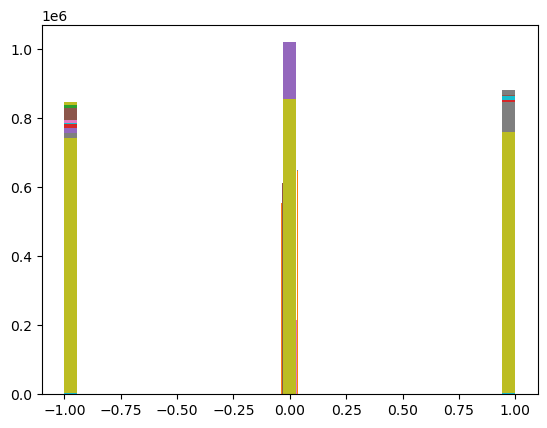

In [89]:
for name,param in model.named_parameters():
    if "weight" in name and "ln" not in name:
        print(name)
        plt.hist(param.data.detach().cpu().flatten(),bins=35)
plt.show()

In [ ]:
share_done = hist["per_layer_share_done"]
shares_done = np.array(share_done)
print(shares_done.shape)
plt.plot(shares_done)
for i in range(shares_done.shape[1]):
    print(shares_done[-1,i])